# 3. projekt

# F1

Oldja meg a következő kezdeti érték feladatot a javított-Euler módszerrel $10,20,50$ lépést használva, ábrázolja és az eredményt hasonlítsa össze az `ode23` által adott-tal:

$$
   y''+y'-ty=t+1\\
$$
$$
y(1)=2\\
$$
$$
y'(1)=0\\
$$
$$
y(2)=?
$$


In [1]:
# javított Euler módszer

import numpy as np

def EulerImp(F, tspan, y0, lepes):
  t = np.linspace(tspan[0], tspan[1], lepes+1)
  y = np.zeros((2, lepes+1))
  h = t[1]-t[0]
  y[:,0] = y0
  for it in range(0,lepes):
    k1 = F(t[it], y[:,it])
    k2 = F(t[it]+h, y[:,it]+k1*h)
    y[:,it+1] = y[:,it]+h*(k1+k2)/2
  return t, y



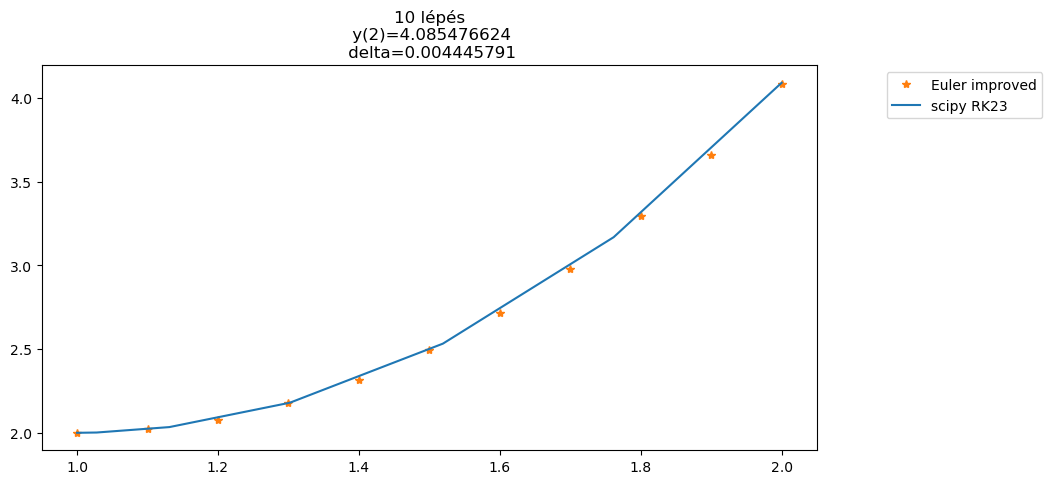

In [7]:
# explicit alak jobboldala: f
f = lambda t,y,dy: t+1+t*y-dy

# a kapcsolódó rendszer jobboldala
F = lambda t,v: np.array([v[1], f(t,v[0],v[1])])


# kezdeti értékek
t0 = 1 
tv = 2
tspan = [t0, tv]
y0 = np.array([2,0])

nstep = 10
tE, yE = EulerImp(F,tspan,y0,nstep)
yE = yE[0]


# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
import scipy as sc
rk23 = sc.integrate.solve_ivp(F, tspan, y0, method = "RK23")
t23 = rk23.t     
y23 = rk23.y[0]  



import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=10,5


fig, ax = plt.subplots()

ax.plot(tE, yE, "*", color = "tab:orange")
ax.plot(t23, y23, color = "tab:blue")

plt.legend(
  ["Euler improved", "scipy RK23"],
  bbox_to_anchor=(1.3, 1.0)
)
plt.title(f"{nstep} lépés\n y({tv})={yE[-1]:.9f}\n delta={np.abs(yE[-1]-y23[-1]):.9f}")
plt.show()

